# 🧠 Superstore Dataset – Advanced EDA with Interactive Visuals

This notebook provides **advanced Exploratory Data Analysis (EDA)** with both **static (Matplotlib + Seaborn)** and **interactive (Plotly)** visuals for the Superstore dataset.

---

## 1. Setup & Imports

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import squarify

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)


df = pd.read_excel(r"C:\Users\ACM\Documents\GitHub\Infotact-team-9\Superstore Analysis\Week 1\Data\Sample - Superstore.xlsx")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-08-11 00:00:00,2016-11-11 00:00:00,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-08-11 00:00:00,2016-11-11 00:00:00,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-12-06 00:00:00,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-11-10 00:00:00,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-11-10 00:00:00,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## 2. Data Overview

In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [64]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Row ID,9994.0,NaN,NaN,NaN,4997.5,2885.163629,1.0,2499.25,4997.5,7495.75,9994.0
Order ID,9994,5009,CA-2017-100111,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Order Date,9994,1237,2016-05-09 00:00:00,38,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ship Date,9994,1334,12/16/2015,35,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ship Mode,9994,4,Standard Class,5968,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer ID,9994,793,WB-21850,37,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer Name,9994,793,William Brown,37,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Segment,9994,3,Consumer,5191,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,9994,1,United States,9994,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,9994,531,New York City,915,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Enhanced Correlation Heatmap

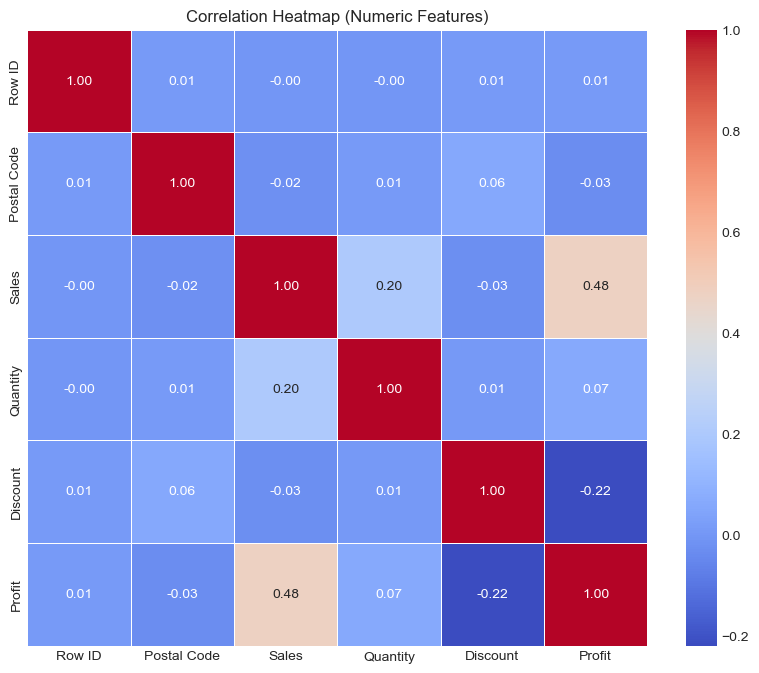

In [65]:
num_cols = df.select_dtypes(include=[np.number]).columns
corr = df[num_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap (Numeric Features)')
plt.show()

## 4. Category & Sub-Category Sales vs Profit

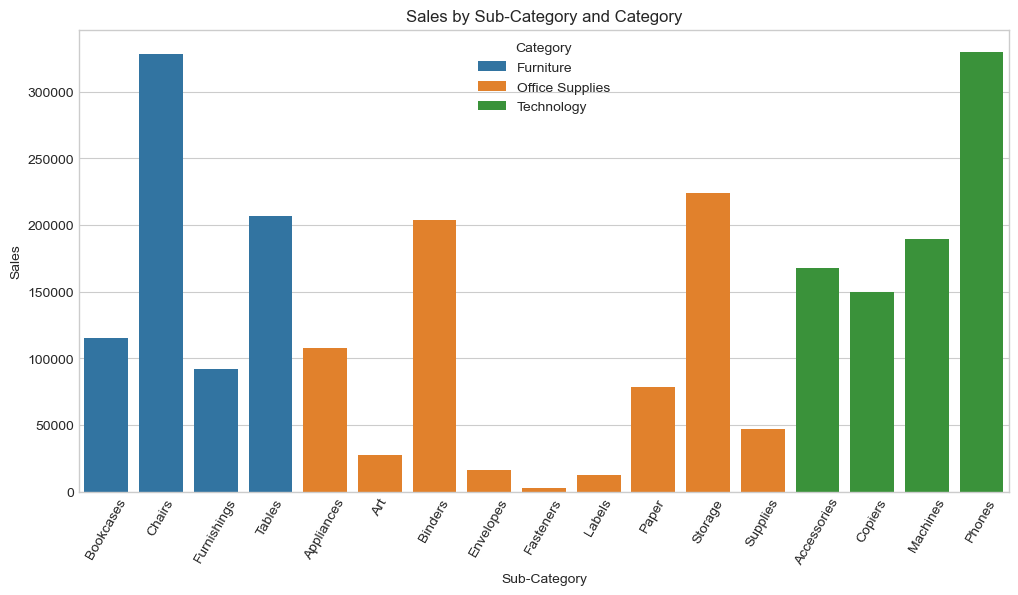

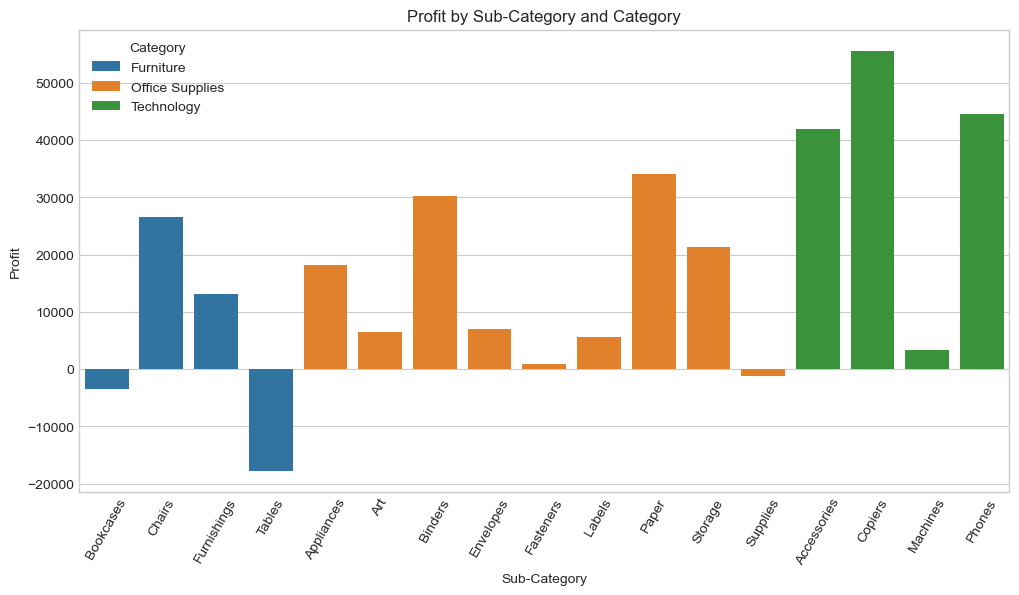

In [66]:
if set(['Category','Sub-Category','Sales','Profit']).issubset(df.columns):
    sub = df.groupby(['Category','Sub-Category'])[['Sales','Profit']].sum().reset_index()
    plt.figure(figsize=(12,6))
    ax = sns.barplot(data=sub, x='Sub-Category', y='Sales', hue='Category')
    plt.xticks(rotation=60)
    plt.title('Sales by Sub-Category and Category')
    plt.show()

    plt.figure(figsize=(12,6))
    sns.barplot(data=sub, x='Sub-Category', y='Profit', hue='Category')
    plt.xticks(rotation=60)
    plt.title('Profit by Sub-Category and Category')
    plt.show()

## 5. Profit vs Discount (Colored by Category)

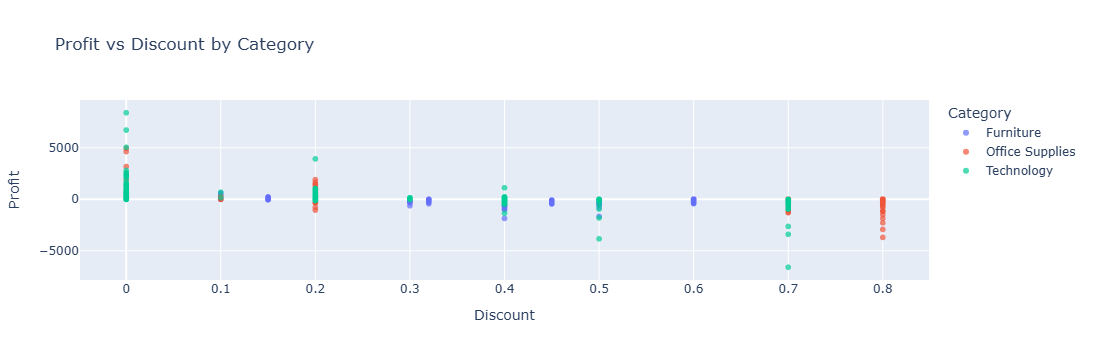

In [67]:
if set(['Discount','Profit','Category']).issubset(df.columns):
    fig = px.scatter(df, x='Discount', y='Profit', color='Category', hover_data=['Sub-Category','Sales'],
                     title='Profit vs Discount by Category', opacity=0.7)
    fig.show()

## 6. Regional Performance Heatmap

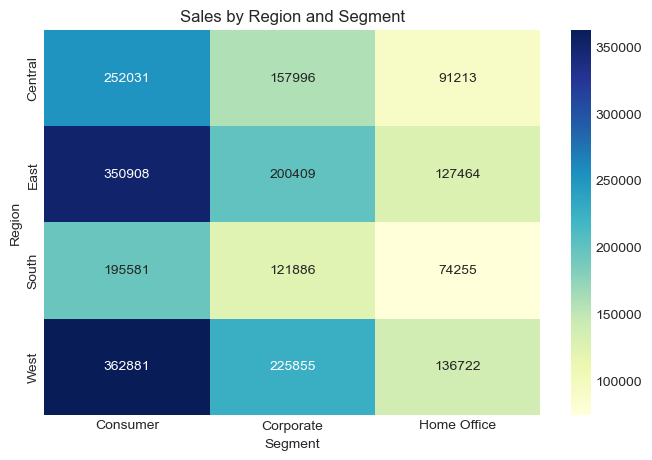

In [68]:
if set(['Region','Segment','Sales']).issubset(df.columns):
    pivot = pd.pivot_table(df, values='Sales', index='Region', columns='Segment', aggfunc='sum')
    plt.figure(figsize=(8,5))
    sns.heatmap(pivot, annot=True, cmap='YlGnBu', fmt='.0f')
    plt.title('Sales by Region and Segment')
    plt.show()

## 7. Time Series: Monthly Sales with Rolling Average

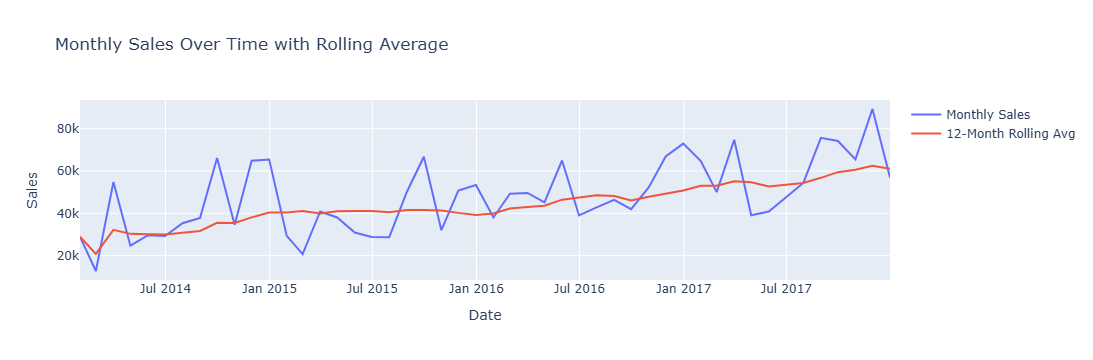

In [69]:
if 'Order Date' in df.columns and 'Sales' in df.columns:
    df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')
    ts = df.groupby(pd.Grouper(key='Order Date', freq='ME'))['Sales'].sum().reset_index()
    ts['Rolling'] = ts['Sales'].rolling(window=12, min_periods=1).mean()

    fig = go.Figure()
    fig.add_trace(go.Scatter(x=ts['Order Date'], y=ts['Sales'], mode='lines', name='Monthly Sales'))
    fig.add_trace(go.Scatter(x=ts['Order Date'], y=ts['Rolling'], mode='lines', name='12-Month Rolling Avg'))
    fig.update_layout(title='Monthly Sales Over Time with Rolling Average', xaxis_title='Date', yaxis_title='Sales')
    fig.show()

## 8. Top 20 Products Treemap

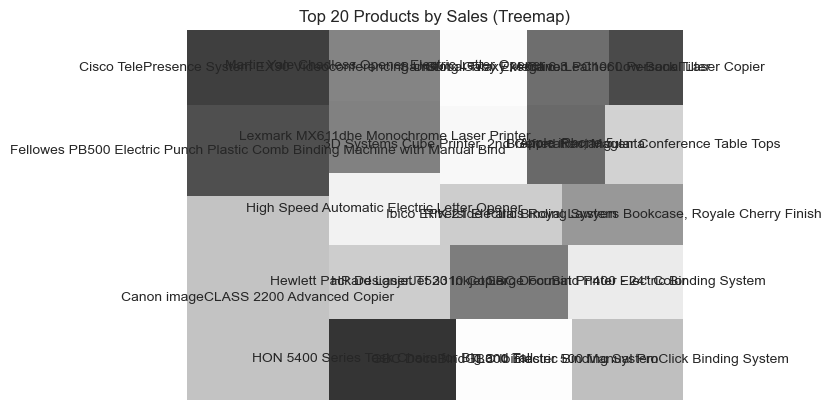

In [70]:
if set(['Product Name','Sales']).issubset(df.columns):
    top20 = df.groupby('Product Name')['Sales'].sum().nlargest(20).reset_index()
    squarify.plot(sizes=top20['Sales'], label=top20['Product Name'], alpha=0.8)
    plt.axis('off')
    plt.title('Top 20 Products by Sales (Treemap)')
    plt.show()

## 9. Profit Share by Ship Mode (Donut Chart)

In [71]:
if set(['Ship Mode','Profit']).issubset(df.columns):
    ship_profit = df.groupby('Ship Mode')['Profit'].sum().reset_index()
    fig = go.Figure(data=[go.Pie(labels=ship_profit['Ship Mode'], values=ship_profit['Profit'], hole=0.4)])
    fig.update_layout(title_text='Profit Share by Ship Mode')
    fig.show()

## 10. Sales Heatmap by Year & Month

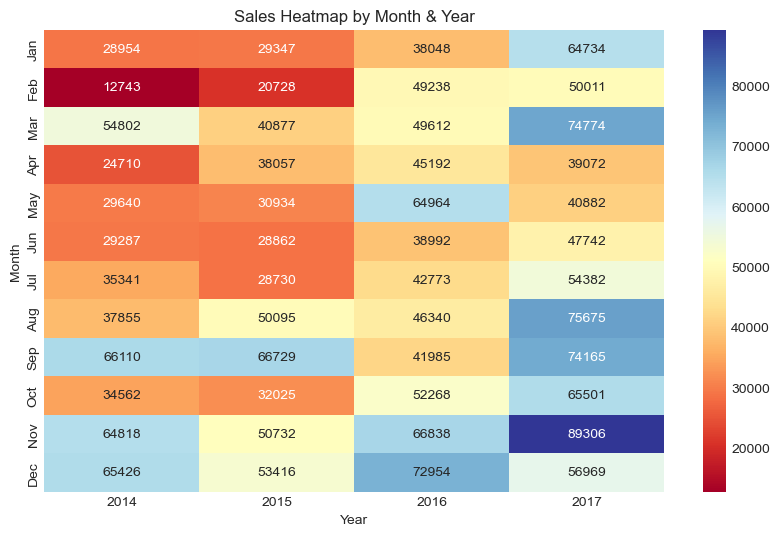

In [73]:
if 'Order Date' in df.columns and 'Sales' in df.columns:
    df['Year'] = df['Order Date'].dt.year
    df['Month'] = df['Order Date'].dt.month_name().str[:3]
    pivot = pd.pivot_table(df, values='Sales', index='Month', columns='Year', aggfunc='sum')
    months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
    pivot = pivot.reindex(months)
    plt.figure(figsize=(10,6))
    sns.heatmap(pivot, annot=True, fmt='.0f', cmap='RdYlBu')
    plt.title('Sales Heatmap by Month & Year')
    plt.show()

## 11. Profit Distribution by Segment

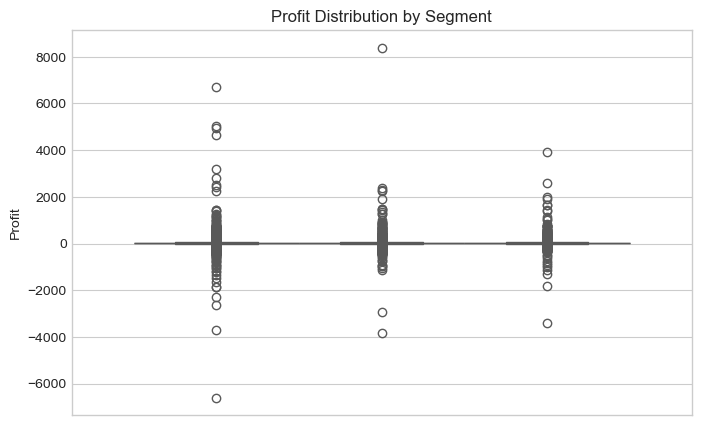

In [74]:
if set(['Segment','Profit']).issubset(df.columns):
    plt.figure(figsize=(8,5))
    sns.boxplot(data=df, hue='Segment', y='Profit', palette='Set2',legend=False)
    plt.title('Profit Distribution by Segment')
    plt.show()

## 12. Interactive Dashboard (Plotly)

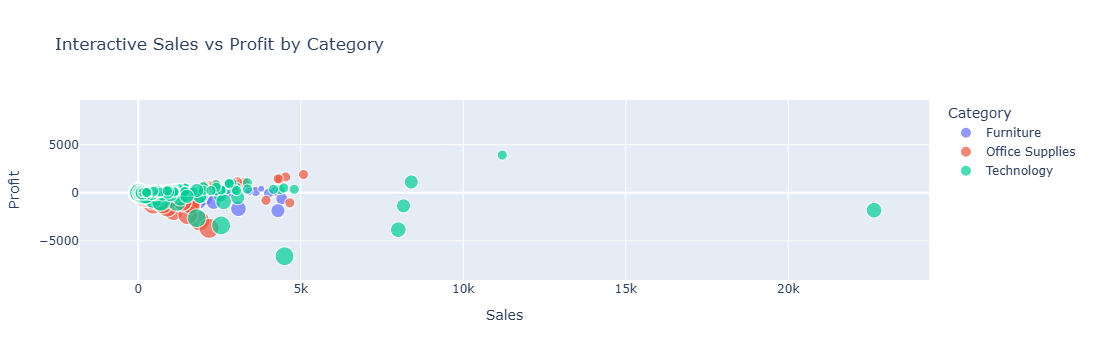

In [75]:
if set(['Category','Sales','Profit','Discount']).issubset(df.columns):
    fig = px.scatter(df, x='Sales', y='Profit', color='Category', size='Discount',
                     hover_data=['Sub-Category','Region','Segment'], title='Interactive Sales vs Profit by Category')
    fig.show()

## ✅ Summary of Insights

- Sales and Profit patterns across multiple dimensions (Category, Region, Segment)
- Discount impact on Profit visualized with interactive scatter plots
- Temporal sales trends and rolling averages
- Treemap visualization for top products
- Profitability breakdown by shipping method and customer segments

---
**Next Steps:**
- Build predictive models for sales/profit
- Optimize discount and product mix strategy
- Implement RFM segmentation for customer retention

# 🌍 Interactive Region & Segment Dashboard
This section adds advanced **Plotly interactive dashboards** to explore Superstore sales and profit patterns by **Region** and **Segment**.

## 1. Region-wise Sales & Profit Bubble Chart

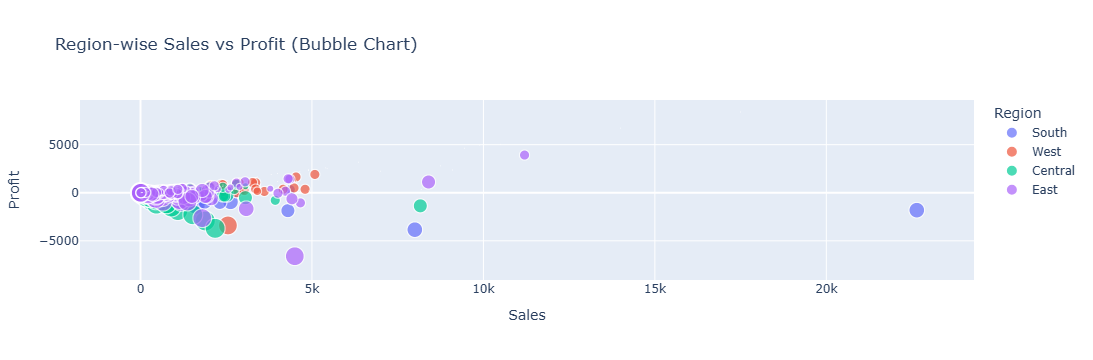

In [76]:
if set(['Region','Sales','Profit','Discount','Segment','Category','Sub-Category']).issubset(df.columns):
    fig = px.scatter(df, x='Sales', y='Profit', color='Region', size='Discount',
                     hover_data=['Segment','Category','Sub-Category'], opacity=0.7,
                     title='Region-wise Sales vs Profit (Bubble Chart)')
    fig.show()

## 2. Category vs Segment Treemap

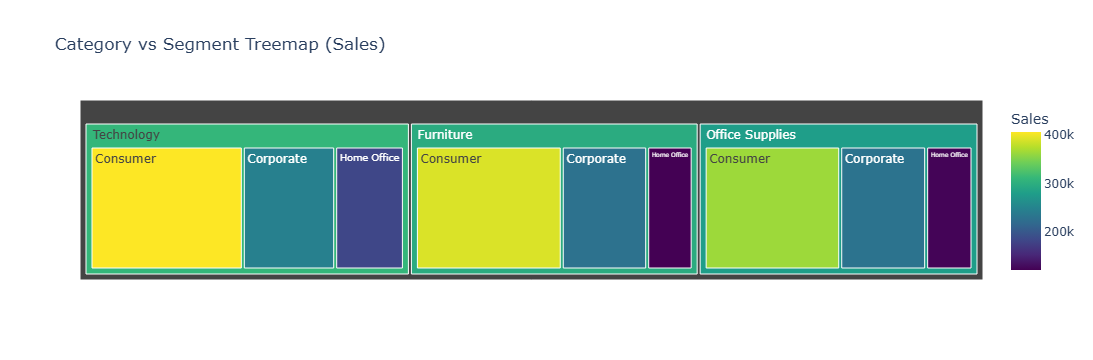

In [77]:
if set(['Category','Segment','Sales']).issubset(df.columns):
    treemap_data = df.groupby(['Category','Segment'])['Sales'].sum().reset_index()
    fig = px.treemap(treemap_data, path=['Category','Segment'], values='Sales',
                     color='Sales', color_continuous_scale='Viridis',
                     title='Category vs Segment Treemap (Sales)')
    fig.show()

## 3. Region–Segment Interactive Heatmap

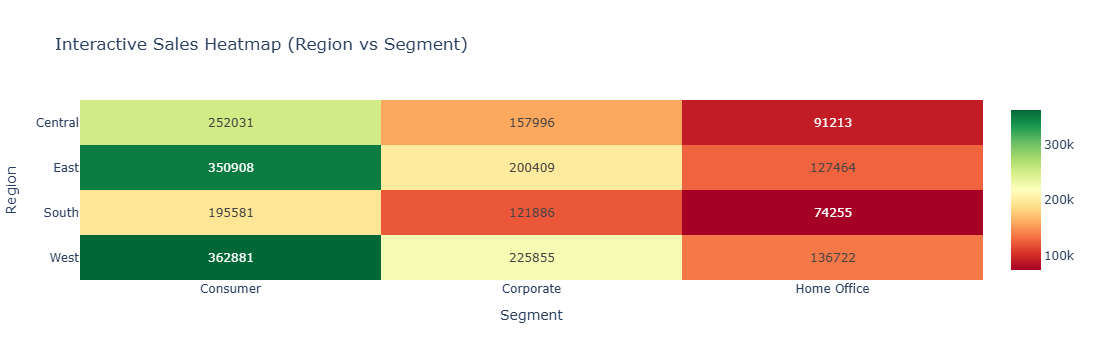

In [78]:
if set(['Region','Segment','Sales']).issubset(df.columns):
    pivot = pd.pivot_table(df, values='Sales', index='Region', columns='Segment', aggfunc='sum').reset_index()
    fig = px.imshow(pivot.set_index('Region'), text_auto='.0f', aspect='auto',
                    color_continuous_scale='RdYlGn', title='Interactive Sales Heatmap (Region vs Segment)')
    fig.show()

## 4. Region Filtered Bar Chart (Sales & Profit by Category)

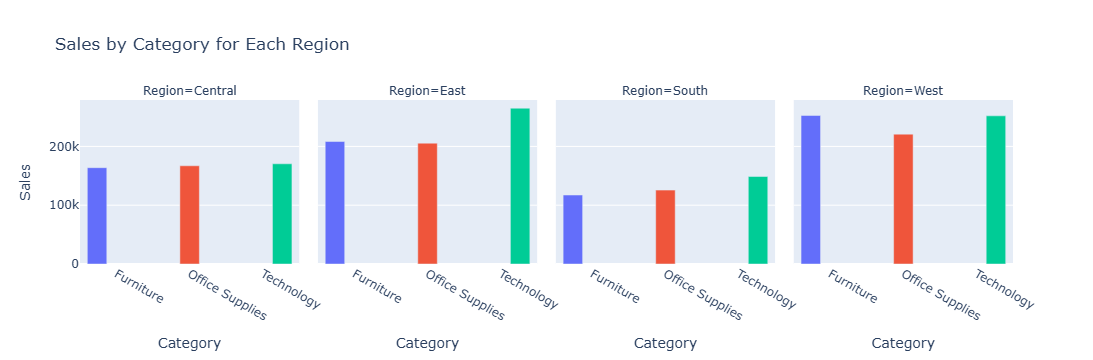

In [79]:
if set(['Region','Category','Sales','Profit']).issubset(df.columns):
    region_summary = df.groupby(['Region','Category'])[['Sales','Profit']].sum().reset_index()

    fig = px.bar(region_summary, x='Category', y='Sales', color='Category',
                 facet_col='Region', barmode='group',
                 hover_data=['Profit'], title='Sales by Category for Each Region')
    fig.update_layout(showlegend=False)
    fig.show()

# ⚙️ Interactive Filtering Section
This section introduces **dropdown-based filters** for dynamic data exploration using Plotly.

## 1. Region Dropdown Filter – Sales vs Profit by Category

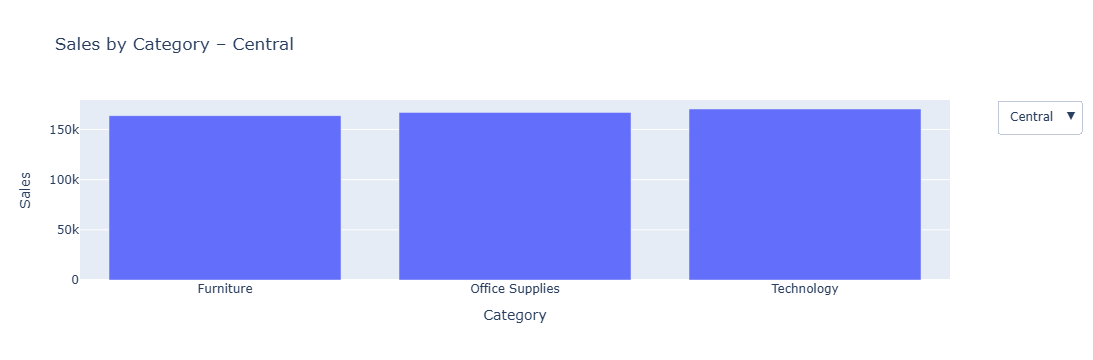

In [80]:
if set(['Region','Category','Sales','Profit']).issubset(df.columns):
    region_summary = df.groupby(['Region','Category'])[['Sales','Profit']].sum().reset_index()

    # Create figure with dropdown for region filtering
    regions = region_summary['Region'].unique()
    fig = go.Figure()
    for r in regions:
        subset = region_summary[region_summary['Region'] == r]
        fig.add_trace(go.Bar(x=subset['Category'], y=subset['Sales'], name=r, visible=(r==regions[0])))

    # Dropdown menu
    buttons = []
    for i, r in enumerate(regions):
        visible = [False]*len(regions)
        visible[i] = True
        buttons.append(dict(label=r, method='update', args=[{'visible': visible}, {'title': f'Sales by Category – {r}'}]))

    fig.update_layout(
        updatemenus=[dict(active=0, buttons=buttons, x=1.15, y=1)],
        title=f'Sales by Category – {regions[0]}',
        xaxis_title='Category',
        yaxis_title='Sales'
    )
    fig.show()

## 2. Year Dropdown Filter – Monthly Sales Trend

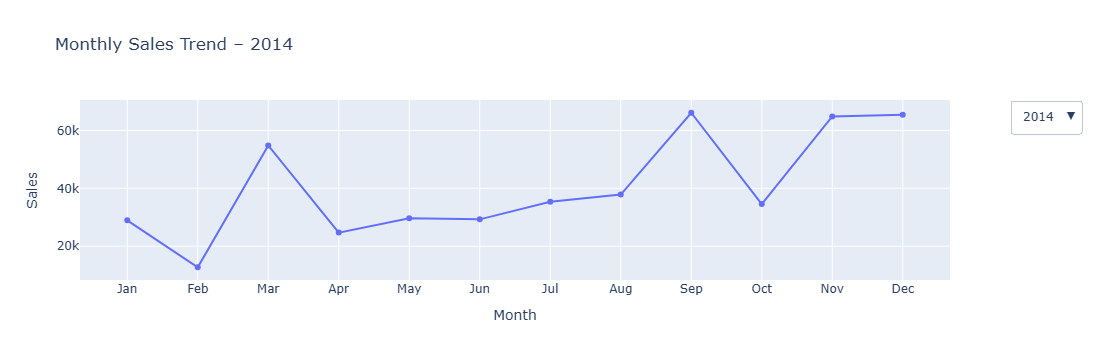

In [81]:
if 'Order Date' in df.columns and 'Sales' in df.columns:
    df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')
    df['Year'] = df['Order Date'].dt.year
    df['Month'] = df['Order Date'].dt.month_name().str[:3]

    monthly_sales = df.groupby(['Year','Month'])['Sales'].sum().reset_index()
    years = sorted(monthly_sales['Year'].dropna().unique())
    months_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

    fig = go.Figure()
    for y in years:
        subset = monthly_sales[monthly_sales['Year'] == y]
        subset = subset.set_index('Month').reindex(months_order)
        fig.add_trace(go.Scatter(x=months_order, y=subset['Sales'], mode='lines+markers', name=str(y), visible=(y==years[0])))

    buttons = []
    for i, y in enumerate(years):
        visible = [False]*len(years)
        visible[i] = True
        buttons.append(dict(label=str(y), method='update', args=[{'visible': visible}, {'title': f'Monthly Sales Trend – {y}'}]))

    fig.update_layout(
        updatemenus=[dict(active=0, buttons=buttons, x=1.15, y=1)],
        title=f'Monthly Sales Trend – {years[0]}',
        xaxis_title='Month', yaxis_title='Sales'
    )
    fig.show()

## 3. Category Filtered Scatter – Profit vs Discount

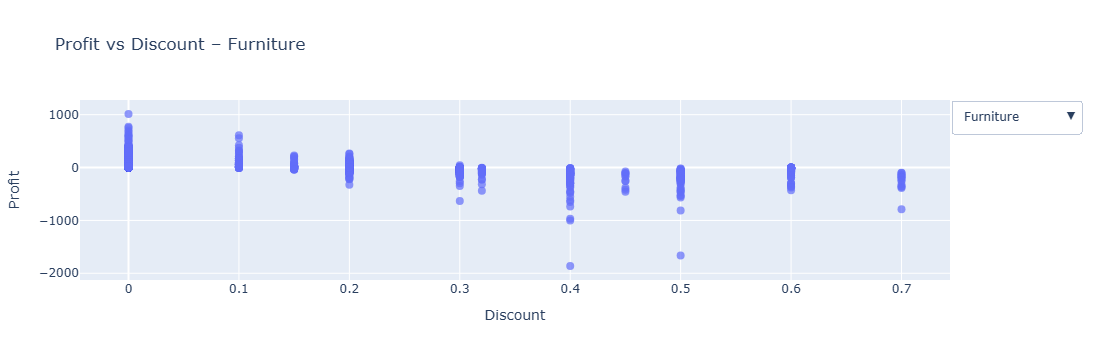

In [82]:
if set(['Category','Profit','Discount','Sub-Category']).issubset(df.columns):
    categories = df['Category'].unique()
    fig = go.Figure()
    for c in categories:
        subset = df[df['Category'] == c]
        fig.add_trace(go.Scatter(x=subset['Discount'], y=subset['Profit'], mode='markers', name=c, visible=(c==categories[0]),
                                 text=subset['Sub-Category'], marker=dict(size=8, opacity=0.7)))

    buttons = []
    for i, c in enumerate(categories):
        visible = [False]*len(categories)
        visible[i] = True
        buttons.append(dict(label=c, method='update', args=[{'visible': visible}, {'title': f'Profit vs Discount – {c}'}]))

    fig.update_layout(
        updatemenus=[dict(active=0, buttons=buttons, x=1.15, y=1)],
        title=f'Profit vs Discount – {categories[0]}',
        xaxis_title='Discount', yaxis_title='Profit'
    )
    fig.show()